# Recall Probability by Lag

> Quantify the spacing effect: how recall improves with wider repetition spacing.

The spacing effect is a well-established memory phenomenon: repeated items benefit from wider spacing between presentations. Recall probability by lag (RPL) quantifies this by computing recall rate as a function of the number of intervening items between repeated presentations.

Two display modes are available: *binned* groups lags into coarse intervals (0, 1–2, 3–5, 6–8) for visualization, while *full* shows every lag bucket individually.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.rpl import (
    infer_max_lag,
    plot_full_rpl,
    plot_rpl,
    subject_binned_rpl,
    subject_full_rpl,
    test_rpl_slope,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
data_path = "../datasets/prepared/BroitmanKahana2024.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, 1]
trial_query = "data['listLength'] > 0"
mode = "full"
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)
max_lag = infer_max_lag(data['pres_itemnos'], data['pres_itemnos'].shape[1])
plotting_function = plot_rpl if mode == "binned" else plot_full_rpl
subject_function = subject_binned_rpl if mode == "binned" else subject_full_rpl

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


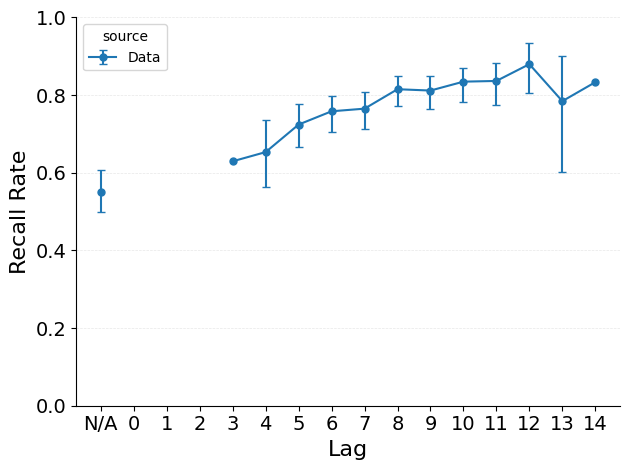

In [4]:
plotting_function(
    data,
    trial_mask,
    labels=["Data"],
    contrast_name="source",
    confidence_level=confidence_level,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

In [5]:
subject_rpl = subject_function(data, trial_mask, max_lag=max_lag)
result = test_rpl_slope(subject_rpl, mode=mode)

print("=" * 60)
print("Spacing Effect Slope")
print("=" * 60)
print(result)

Spacing Effect Slope
N=33
Mean slope: 0.0205
t-stat: 4.436 p=0.0001
W-stat: 62.0 p=0.0000


## Interpretation

The plot shows recall probability as a function of repetition spacing (number of intervening items). Key patterns:

- **Positive slope**: recall probability increases with wider spacing, demonstrating the spacing effect.
- **Slope test**: the statistical test quantifies whether the spacing slope is reliably positive.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a list, or `None` for automatic scaling.
- `trial_query` — query selecting trials.
- `mode` — `"binned"` for coarse lag groups or `"full"` for individual lag buckets.
- `confidence_level` — confidence level for subject-wise error bars.